In [1]:
#from py21cmemu import Emulator
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import optuna
from optuna.trial import TrialState

import copy
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.set_num_threads(60)

In [2]:
from cmEMU_functions import lhs_sampler, get_output, get_21cmfast_input_and_output, corner_plot, plotting_PS, get_unique, low_PS, plotting_Wk_vs_k, EarlyStopping, PSNN

Matplotlib is building the font cache; this may take a moment.


In [3]:
fast_train_in, fast_train_out, emu_train_out = get_21cmfast_input_and_output('Tr')
fast_val_in, fast_val_out, emu_val_out = get_21cmfast_input_and_output('V')
fast_test_in, fast_test_out, emu_test_out = get_21cmfast_input_and_output('T')
emu_train_out = get_unique(emu_train_out)
emu_val_out = get_unique(emu_val_out)
emu_test_out = get_unique(emu_test_out)

training_rounds = 17
t = lhs_sampler(num_rounds = training_rounds, label = 'TrainingData')
train_input = t.drop(['Round'], axis = 1).to_numpy()

train_output = get_output(17, 'TrainingData')
final_train = get_unique(train_output)

val_output = get_output(17, 'ValidationData')
final_val = get_unique(val_output)

test_output = get_output(33, 'TrainingData')
final_test = get_unique(test_output)

Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading emulated round 1
Loading emulated round 2
Loading emulated round 3
Loading emulated round 4
Loading emulated round 5
Loading emulated round 6
Loading emulated round 7
Loading emulated round 8
Loading emulated round 9
Loading emulated round 10
Loading emulated round 11
Loading emulated round 12
Loading emulated round 13
Loading emulated round 14
Loading emulated round 15
Loading emulated round 16
Loading emulated round 17
Loading emulated round 1
Loading emulated round 2
Loading emulated round 3
Loading emulated round 4
Loading emulated round 5
Loading emulated round 6
Loading emulated round 7
Loading emulated round 8
Loading emulated round 9
Loading emulated round 10
Loading emulated round 11
Loading emulated round 12
Loading emulated round 13
Loading emulated round 14
Loading emulated round 15
Loading emulated round 16
Loading emulated round 1

In [4]:
np.shape(emu_train_out.PS)

(168, 60, 12)

In [5]:
np.shape(fast_train_in)

(168, 9)

In [6]:
te = lhs_sampler(33, 'TestData')
test_input = te.drop(['Round'], axis = 1).to_numpy()

Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading
Loading


In [7]:
#Scalers for 21cmFAST(freeze)

input_scaler = MinMaxScaler()

train_input_scale = input_scaler.fit_transform(train_input)
test_input_scaled = input_scaler.transform(test_input)

fast_train_input_scaled = input_scaler.transform(fast_train_in.to_numpy())
fast_validation_input_scaled = input_scaler.transform(fast_val_in.to_numpy())
fast_test_input_scaled = input_scaler.transform(fast_test_in.to_numpy())

fast_high_res_out_scaler = MinMaxScaler()

fast_train_out = fast_train_out[:, :, :13]
fast_val_out = fast_val_out[:, :, :13]
fast_test_out = fast_test_out[:, :, :13]

fast_train_target_2D = np.log10(np.reshape(fast_train_out, (np.shape(fast_train_out)[0], -1)).astype('float64'))
fast_validation_target_2D = np.log10(np.reshape(fast_val_out, (np.shape(fast_val_out)[0], -1)).astype('float64'))
fast_test_target_2D = np.log10(np.reshape(fast_test_out, (np.shape(fast_test_out)[0], -1)).astype('float64'))

#replacing nan and -inf with 0
fast_train_target_2D[np.isnan(fast_train_target_2D)] = -10
fast_train_target_2D[np.where(fast_train_target_2D == -np.inf)] = -10
fast_validation_target_2D[np.isnan(fast_validation_target_2D)] = -10
fast_validation_target_2D[np.where(fast_validation_target_2D == -np.inf)] = -10
fast_test_target_2D[np.isnan(fast_test_target_2D)] = -10
fast_test_target_2D[np.where(fast_test_target_2D == -np.inf)] = -10

fast_train_target_scaled = fast_high_res_out_scaler.fit_transform(fast_train_target_2D)
fast_validation_target_scaled = fast_high_res_out_scaler.transform(fast_validation_target_2D)
fast_test_target_scaled = fast_high_res_out_scaler.transform(fast_test_target_2D)

fast_high_train_3D = np.reshape(fast_train_target_scaled, (np.shape(fast_train_out)))
fast_high_val_3D = np.reshape(fast_validation_target_scaled, (np.shape(fast_val_out)))

train_dataset = TensorDataset(torch.tensor(fast_train_input_scaled, dtype = torch.float64),
                              torch.tensor(fast_high_train_3D, dtype = torch.float64))
validation_dataset = TensorDataset(torch.tensor(fast_validation_input_scaled, dtype = torch.float64),
                                   torch.tensor(fast_high_val_3D, dtype = torch.float64))

/tmp/ipykernel_1323034/64687505.py:18: RuntimeWarning: divide by zero encountered in log10
  fast_train_target_2D = np.log10(np.reshape(fast_train_out, (np.shape(fast_train_out)[0], -1)).astype('float64'))
/tmp/ipykernel_1323034/64687505.py:19: RuntimeWarning: divide by zero encountered in log10
  fast_validation_target_2D = np.log10(np.reshape(fast_val_out, (np.shape(fast_val_out)[0], -1)).astype('float64'))
/tmp/ipykernel_1323034/64687505.py:20: RuntimeWarning: divide by zero encountered in log10
  fast_test_target_2D = np.log10(np.reshape(fast_test_out, (np.shape(fast_test_out)[0], -1)).astype('float64'))


In [15]:
np.shape(emu_train_out.PS)

(168, 60, 12)

In [7]:
#Scalers for 21cmFAST(pipeline)


input_scaler = MinMaxScaler()

train_input_scale = input_scaler.fit_transform(train_input)
test_input_scaled = input_scaler.transform(fast_test_in)

low_res_input_scaler = MinMaxScaler()

train_input_2D = np.log10(np.reshape(emu_train_out.PS, (np.shape(emu_train_out.PS)[0], -1))).astype('float64')
val_input_2D = np.log10(np.reshape(emu_val_out.PS, (np.shape(emu_val_out.PS)[0], -1))).astype('float64')
test_input_2D = np.log10(np.reshape(emu_test_out.PS, (np.shape(emu_test_out.PS)[0], -1))).astype('float64')

train_input_2D_scaled = low_res_input_scaler.fit_transform(train_input_2D)
val_input_2D_scaled = low_res_input_scaler.transform(val_input_2D)
test_input_2D_scaled = low_res_input_scaler.transform(test_input_2D)

fast_high_res_out_scaler = MinMaxScaler()

fast_train_out = fast_train_out[:, :, :13]
fast_val_out = fast_val_out[:, :, :13]
fast_test_out = fast_test_out[:, :, :13]

fast_train_target_2D = np.log10(np.reshape(fast_train_out, (np.shape(fast_train_out)[0], -1)).astype('float64'))
fast_validation_target_2D = np.log10(np.reshape(fast_val_out, (np.shape(fast_val_out)[0], -1)).astype('float64'))

#replacing nan and -inf with 0
fast_train_target_2D[np.isnan(fast_train_target_2D)] = -10
fast_train_target_2D[np.where(fast_train_target_2D == -np.inf)] = -10
fast_validation_target_2D[np.isnan(fast_validation_target_2D)] = -10
fast_validation_target_2D[np.where(fast_validation_target_2D == -np.inf)] = -10

fast_train_target_scaled = fast_high_res_out_scaler.fit_transform(fast_train_target_2D)
fast_validation_target_scaled = fast_high_res_out_scaler.transform(fast_validation_target_2D)

fast_high_train_3D = np.reshape(fast_train_target_scaled, (np.shape(fast_train_out)))
fast_high_val_3D = np.reshape(fast_validation_target_scaled, (np.shape(fast_val_out)))

train_dataset = TensorDataset(torch.tensor(train_input_2D_scaled, dtype = torch.float64),
                              torch.tensor(fast_high_train_3D, dtype = torch.float64))
validation_dataset = TensorDataset(torch.tensor(val_input_2D_scaled, dtype = torch.float64),
                                   torch.tensor(fast_high_val_3D, dtype = torch.float64))

/disk/dawn-1/rile7669/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/tmp/ipykernel_2663742/2072948480.py:25: RuntimeWarning: divide by zero encountered in log10
  fast_train_target_2D = np.log10(np.reshape(fast_train_out, (np.shape(fast_train_out)[0], -1)).astype('float64'))
/tmp/ipykernel_2663742/2072948480.py:26: RuntimeWarning: divide by zero encountered in log10
  fast_validation_target_2D = np.log10(np.reshape(fast_val_out, (np.shape(fast_val_out)[0], -1)).astype('float64'))


# 9 FREE PARAMETERS

Input Data to Low Res:


Sigmoid:  [1926, 1535, 1264], lr = 0.001777, batch_size = 32. Optuna Score: 0.00029

SharpCut: [1624, 1414, 1336], lr = 0.003022, batch_size = 128. Optuna score: 0.00021


Low Res to High Res:

Sigmoid: [1957, 1867, 1185], lr = 0.000736, batch_size = 64

SharpCut: [1612, 1302], lr = 0.000893, batch_size = 512

In [18]:
model = PSNN(720, [1957, 1867, 1185], 'FAST')
model = model.double()
# model.load_state_dict(torch.load(
#     "PSNN Trained Models1/PSNN_9free_EMU_InputToEMURes_50k.pth", 
#     map_location=torch.device('cpu')))
criterion = nn.MSELoss()



batch_size = 64
lr = 0.000736

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)  # For Freeze out
early_stopper = EarlyStopping(patience = 100, delta = 0.0005, verbose = True)

train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, num_workers = 8)
val_loader = DataLoader(validation_dataset, batch_size = batch_size, shuffle = True, num_workers = 8)


epochs = 500

best_val_loss = float('inf')

for epoch in range(epochs):

    model.train()

    for batch_x, batch_y in train_loader:
        #batch_x, batch_y = batch_x.to(device, non_blocking = True), batch_y.to(device, non_blocking = True) for gpu
        optimizer.zero_grad(set_to_none = True)
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1} | Loss: {loss.item():.4f}')

    model.eval()
    val_loss = 0

    with torch.inference_mode():

        for batch_x, batch_y in val_loader:
            #batch_x, batch_y = batch_x.to(device, non_blocking = True), batch_y.to(device, non_blocking = True)

            output = model(batch_x)
            val_loss += criterion(output, batch_y).item()

    val_loss /= len(val_loader)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(model.state_dict())

        torch.save(model.state_dict(), 'PSNN Trained Models1/PSNN_EMU_to_FAST_2nd_emulator.pth')

    early_stopper.check_early_stop(val_loss)
    if early_stopper.stop_training:
        print(f'Early stopping at epoch {epoch} | Best Loss : {best_val_loss}')
        break

if best_model_weights is not None:
    model.load_state_dict(best_model_weights)


Epoch 10 | Loss: 0.0447
Epoch 20 | Loss: 0.0278
Epoch 30 | Loss: 0.0195
Epoch 40 | Loss: 0.0140
Epoch 50 | Loss: 0.0108
Epoch 60 | Loss: 0.0105
Epoch 70 | Loss: 0.0087
Epoch 80 | Loss: 0.0079
Epoch 90 | Loss: 0.0069
Epoch 100 | Loss: 0.0070
Epoch 110 | Loss: 0.0055
Epoch 120 | Loss: 0.0058
Epoch 130 | Loss: 0.0057
Epoch 140 | Loss: 0.0049
Epoch 150 | Loss: 0.0041
Epoch 160 | Loss: 0.0048
Epoch 170 | Loss: 0.0044
Epoch 180 | Loss: 0.0039
Epoch 190 | Loss: 0.0036
Epoch 200 | Loss: 0.0038
Epoch 210 | Loss: 0.0030
Epoch 220 | Loss: 0.0041
Epoch 230 | Loss: 0.0038
Epoch 240 | Loss: 0.0032
Epoch 250 | Loss: 0.0037
Epoch 260 | Loss: 0.0029
Epoch 270 | Loss: 0.0031
Epoch 280 | Loss: 0.0032
Stopping early as no improvement has been observed.
Early stopping at epoch 285 | Best Loss : 0.0032999686401651218


In [9]:
#Test neural network on test data
loaded_model_intolow = PSNN(9, [1957, 1867, 1185], label = 'EMU')
loaded_model_intolow = loaded_model_intolow.double()
loaded_model_intolow.load_state_dict(torch.load('PSNN Trained Models1/PSNN_9free_EMU_InputToEMURes_50k.pth', map_location=torch.device('cpu')))

loaded_model_lowtohigh = PSNN(720, [236], label = 'FAST')
loaded_model_lowtohigh = loaded_model_lowtohigh.double()
loaded_model_lowtohigh.load_state_dict(torch.load('PSNN Trained Models1/PSNN_EMU_to_FAST_2nd_emulator_optimized.pth', map_location=torch.device('cpu')))

loaded_model_intolow.eval()
loaded_model_lowtohigh.eval()

with torch.inference_mode():
    input_data = torch.tensor(test_input_scaled, dtype = torch.float64)
    
    low_pred = loaded_model_intolow(input_data)
    low_pred_flat = low_pred.view(low_pred.shape[0], -1)

    high_pred = loaded_model_lowtohigh(low_pred_flat)


y_pred_scaled_2D = high_pred.cpu().numpy().reshape(high_pred.cpu().numpy().shape[0], -1)
y_pred_log_2D = fast_high_res_out_scaler.inverse_transform(y_pred_scaled_2D)  # unscale the predicted data, have to make it 2D first

y_pred_3D = y_pred_log_2D.reshape(-1, 60, 13)
y_true_3D = np.log10(fast_test_out).reshape(-1, 60, 13)
y_true_full_2D = y_true_3D.reshape(y_true_3D.shape[0], -1)
y_pred_full_2D = y_pred_3D.reshape(y_pred_3D.shape[0], -1)


y_true_3D[np.isnan(y_true_3D)] = -10
y_true_3D[np.isinf(y_true_3D)] = -10


pred_high_res_3D = y_pred_3D[:, :, -3:] 
true_high_res_3D = y_true_3D[:, :, -3:]

pred_low_res_3D = y_pred_3D[:, :, :-3]
true_low_res_3D = y_true_3D[:, :, :-3]

pred_high_res_2D = pred_high_res_3D.reshape(pred_high_res_3D.shape[0], -1)
true_high_res_2D = true_high_res_3D.reshape(true_high_res_3D.shape[0], -1)

pred_low_res_2D = pred_low_res_3D.reshape(pred_low_res_3D.shape[0], -1)
true_low_res_2D = true_low_res_3D.reshape(true_low_res_3D.shape[0], -1)


r2_high = r2_score(true_high_res_2D, pred_high_res_2D)
r2_low = r2_score(true_low_res_2D, pred_low_res_2D)
r2_global = r2_score(y_true_full_2D, y_pred_full_2D)



print(r2_high)
print(r2_low)
print(r2_global)

0.8584856990944565
0.7844268093628891
0.8015173223778663


/tmp/ipykernel_2663742/302570474.py:26: RuntimeWarning: divide by zero encountered in log10
  y_true_3D = np.log10(fast_test_out).reshape(-1, 60, 13)


In [ ]:
model = PSNN(9, [1957, 1867, 1185], 'FAST')
model = model.double()
pretrained_dict = torch.load(
    "PSNN Trained Models1/PSNN_9free_EMU_InputToEMURes_50k.pth", 
    map_location=torch.device('cpu')
)
del pretrained_dict['net.8.weight']
del pretrained_dict['net.8.bias']
del pretrained_dict['net.9.weight']
del pretrained_dict['net.9.bias']
del pretrained_dict['net.12.weight']
del pretrained_dict['net.12.bias']

model.load_state_dict(pretrained_dict, strict = False)  # Feeze and do transfer learning


#Freezing and unfreezing the relevant layers.

for params in model.net.parameters():
    params.requires_grad = False

for params in model.net[8:].parameters():
    params.requires_grad = True

criterion = nn.MSELoss()

batch_size = 64
lr = 0.000736

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)  # For Freeze out
early_stopper = EarlyStopping(patience = 100, delta = 0.0005, verbose = True)

train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, num_workers = 8)
val_loader = DataLoader(validation_dataset, batch_size = batch_size, shuffle = True, num_workers = 8)


epochs = 500

best_val_loss = float('inf')

for epoch in range(epochs):

    model.train()

    for batch_x, batch_y in train_loader:
        #batch_x, batch_y = batch_x.to(device, non_blocking = True), batch_y.to(device, non_blocking = True) for gpu
        optimizer.zero_grad(set_to_none = True)
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1} | Loss: {loss.item():.4f}')

    model.eval()
    val_loss = 0

    with torch.inference_mode():

        for batch_x, batch_y in val_loader:
            #batch_x, batch_y = batch_x.to(device, non_blocking = True), batch_y.to(device, non_blocking = True)

            output = model(batch_x)
            val_loss += criterion(output, batch_y).item()

    val_loss /= len(val_loader)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(model.state_dict())

        torch.save(model.state_dict(), 'PSNN Trained Models1/PSNN_EMU_to_FAST.pth')

    early_stopper.check_early_stop(val_loss)
    if early_stopper.stop_training:
        print(f'Early stopping at epoch {epoch} | Best Loss : {best_val_loss}')
        break

if best_model_weights is not None:
    model.load_state_dict(best_model_weights)


Epoch 10 | Loss: 0.0334
Epoch 20 | Loss: 0.0218
Epoch 30 | Loss: 0.0171
Epoch 40 | Loss: 0.0121
Epoch 50 | Loss: 0.0101
Epoch 60 | Loss: 0.0094
Epoch 70 | Loss: 0.0073
Epoch 80 | Loss: 0.0064
Epoch 90 | Loss: 0.0053
Epoch 100 | Loss: 0.0052
Epoch 110 | Loss: 0.0046
Epoch 120 | Loss: 0.0041
Epoch 130 | Loss: 0.0038
Epoch 140 | Loss: 0.0039
Epoch 150 | Loss: 0.0031
Epoch 160 | Loss: 0.0032
Epoch 170 | Loss: 0.0030
Epoch 180 | Loss: 0.0029
Epoch 190 | Loss: 0.0026
Epoch 200 | Loss: 0.0026
Epoch 210 | Loss: 0.0024
Epoch 220 | Loss: 0.0022
Epoch 230 | Loss: 0.0022
Epoch 240 | Loss: 0.0021
Epoch 250 | Loss: 0.0020
Epoch 260 | Loss: 0.0021
Epoch 270 | Loss: 0.0023
Epoch 280 | Loss: 0.0019
Epoch 290 | Loss: 0.0020
Epoch 300 | Loss: 0.0015
Epoch 310 | Loss: 0.0019
Epoch 320 | Loss: 0.0022
Epoch 330 | Loss: 0.0022
Stopping early as no improvement has been observed.
Early stopping at epoch 329 | Best Loss : 0.002808679905991858


In [8]:
#Test neural network on test data
loaded_model = PSNN(9, [1957, 1867, 1185], label = 'FAST')
loaded_model = loaded_model.double()
loaded_model.load_state_dict(torch.load('PSNN Trained Models1/PSNN_EMU_to_FAST.pth'))

loaded_model.eval()
with torch.inference_mode():
    input_data = torch.tensor(fast_test_input_scaled, dtype = torch.float64)
    y_pred_tens = loaded_model(input_data)

y_pred_scaled_2D = y_pred_tens.cpu().numpy().reshape(y_pred_tens.cpu().numpy().shape[0], -1)
y_pred_log_2D = fast_high_res_out_scaler.inverse_transform(y_pred_scaled_2D)  # unscale the predicted data, have to make it 2D first

# y_true = np.log10(fast_test_out).reshape(fast_test_out.shape[0], -1)
# y_true[np.isnan(y_true)] = -10
# y_true[np.where(y_true == -np.inf)] = -10

#r2_score(y_true[:,600:], y_pred_log_2D[:,600:])

In [9]:
y_pred_3D = y_pred_log_2D.reshape(-1, 60, 13)
y_true_3D = np.log10(fast_test_out).reshape(-1, 60, 13)
y_true_full_2D = y_true_3D.reshape(y_true_3D.shape[0], -1)
y_pred_full_2D = y_pred_3D.reshape(y_pred_3D.shape[0], -1)

# Handle NaNs/Infs on the 3D true array
y_true_3D[np.isnan(y_true_3D)] = -10
y_true_3D[np.isinf(y_true_3D)] = -10

# ==========================================================
# 3. THE REGIONAL SLICING
# ==========================================================
# We want all samples (:), all redshifts (:), but only the last 4 k-bins (-4:)
pred_high_res_3D = y_pred_3D[:, :, -3:] 
true_high_res_3D = y_true_3D[:, :, -3:]

pred_low_res_3D = y_pred_3D[:, :, :-3]
true_low_res_3D = y_true_3D[:, :, :-3]

# 4. Flatten the sliced regions back to 2D for scikit-learn
# Shape becomes: (samples, 240) for high-res, (samples, 600) for low-res
pred_high_res_2D = pred_high_res_3D.reshape(pred_high_res_3D.shape[0], -1)
true_high_res_2D = true_high_res_3D.reshape(true_high_res_3D.shape[0], -1)

pred_low_res_2D = pred_low_res_3D.reshape(pred_low_res_3D.shape[0], -1)
true_low_res_2D = true_low_res_3D.reshape(true_low_res_3D.shape[0], -1)

# 5. Calculate your isolated scores!
# 5. Calculate your isolated scores!
r2_high = r2_score(true_high_res_2D, pred_high_res_2D)
r2_low = r2_score(true_low_res_2D, pred_low_res_2D)
r2_global = r2_score(y_true_full_2D, y_pred_full_2D)



print(r2_high)
print(r2_low)
print(r2_global)

0.9137082877529473
0.8219117169216122
0.8430955409596127


/tmp/ipykernel_1323034/2600147547.py:2: RuntimeWarning: divide by zero encountered in log10
  y_true_3D = np.log10(fast_test_out).reshape(-1, 60, 13)


In [42]:
np.shape(y_pred_tens[:,:,10:])
np.shape(y_pred_log_2D[:,600:])

(37, 240)

In [14]:
sig_y_pred_tens = y_pred_log_2D.reshape(fast_test_out.shape[0], 60, 14)


In [12]:
sharp_y_pred_tens = y_pred_log_2D.reshape(fast_test_out.shape[0], 60, 14)

In [38]:
def plotting_FAST_PS(true_data, emulated_data, varying, size, k, z, filename):

    import matplotlib.pyplot as plt
    np.random.seed(42311)

    rand = np.random.randint(0, len(true_data), size = size)
    

    fs = 20

    color_families = [
        ('navy', 'royalblue'),          # 1. Blues
        ('darkred', 'crimson'),           # 2. Reds
        ('darkgreen', 'forestgreen'),      # 3. Greens
        ('saddlebrown', 'chocolate'),     # 5. Browns/Oranges
        ('mediumvioletred', 'deeppink')]     # 7. Pinks

    k_values = np.array([0.03820577, 0.05725007, 0.07778031, 0.101638,   0.1347107,  0.1815186,
 0.2444601,  0.3299734,  0.4460977,  0.6021986,  0.8131821,  1.097917, 1.4050565,  1.82823482])
    redshifts = [ 5.90059,   6.038602,  6.179374  ,6.322961  ,6.46942   ,6.618808 , 6.771184,
  6.926608  ,7.08514   ,7.246843,  7.411779  ,7.580015  ,7.751615  ,7.926647,
  8.10518   ,8.287283  ,8.473028,  8.662489  ,8.855739  ,9.052854  ,9.25391,
  9.458988  ,9.668168  ,9.881531, 10.09916  ,10.32114  ,10.54757  ,10.77852,
 11.01409  ,11.25437  ,11.49946, 11.74944  ,12.00443  ,12.26452  ,12.52981,
 12.80041  ,13.07641  ,13.35794,  13.6451   ,13.938    ,14.23676  ,14.5415,
 14.85233  ,15.16937  ,15.49276 , 15.82262  ,16.15907  ,16.50225  ,16.85229,
 17.20934  ,17.57353  ,17.945   , 18.3239   ,18.71038  ,19.10458  ,19.50668,
 19.91681  ,20.33514  ,20.76185  ,21.19708]

    if varying == 'zs':
        

        for i, (c_true, c_em) in zip(rand, color_families):

            plt.plot(redshifts, true_data[i, :, k], lw = 2, ls = '-', color = c_true, alpha = 0.6)
            plt.plot(redshifts, emulated_data[i, :, k], lw = 2, ls = '--', color = c_em, alpha = 0.9)
        
        plt.plot([], [], lw=2, ls='-', color='gray', label='True data')
        plt.plot([], [], lw=2, ls='--', color='gray', label='Predicted data')
        #plt.plot([], [], label = f'$k$ = {k_values[k]:.3f} Mpc$^{-1}$')
        plt.legend(title = f'$k$ = {k_values[k]:.3f} Mpc$^{-1}$', fontsize=10, loc='best')
        
        plt.ylabel(r'$\Delta_{21}^2$ [mk$^2$]', fontsize = fs)
        plt.xlabel(r'Redshift z', fontsize = fs)
        plt.xlim(redshifts[0] - 0.1, redshifts[-1] + 0.1)
        plt.ylim(bottom = 2e-1)
        plt.yticks(fontsize = fs)
        plt.xticks(fontsize = fs)
        plt.yscale('log')
        plt.title('21cmEMU+FAST Power Spectrum', fontsize = fs)
        plt.tight_layout()
        plt.savefig(filename, dpi = 300)
        plt.show()
            
    else:

        for i, (c_true, c_em) in zip(rand, color_families):

            plt.plot(k_values[1:-1], true_data[i, z, :-1], lw = 2, ls = '-', color = c_true, alpha = 0.6)
            plt.plot(k_values[1:-1], emulated_data[i, z, :-1], lw = 2, ls = '--', color = c_em, alpha = 0.9)
        

        plt.plot([], [], lw=2, ls='-', color='gray', label='True data')
        plt.plot([], [], lw=2, ls='--', color='gray', label='Predicted data')
        #plt.plot([], [], label = )
        plt.legend(title = f'z = {redshifts[z]:.3f}',fontsize=10, loc='best')
    
        plt.ylabel(r'$\Delta_{21}^2$ [mk$^2$]', fontsize = fs)
        plt.xlabel(r'k (Mpc$^{-1}$)', fontsize = fs)
        plt.xlim(k_values[3] - 1e-2, k_values[-2] + 1e-2)
        plt.ylim(bottom = 1)
        plt.yticks(fontsize = fs)
        plt.xticks(fontsize = fs)
        plt.yscale('log')
        plt.title('21cmEMU+FAST Power Spectrum', fontsize = fs)
        plt.tight_layout()
        plt.savefig(filename, dpi = 300)
        plt.show()


In [14]:
k_values = np.array([0.03820577, 0.05725007, 0.07778031, 0.101638,   0.1347107,  0.1815186,
 0.2444601,  0.3299734,  0.4460977,  0.6021986,  0.8131821,  1.097917, 1.4050565,  1.82823482])
print(np.shape(k_values[1:]))
print(np.shape(fast_test_out[:, :, 1:]))

(13,)
(37, 60, 12)


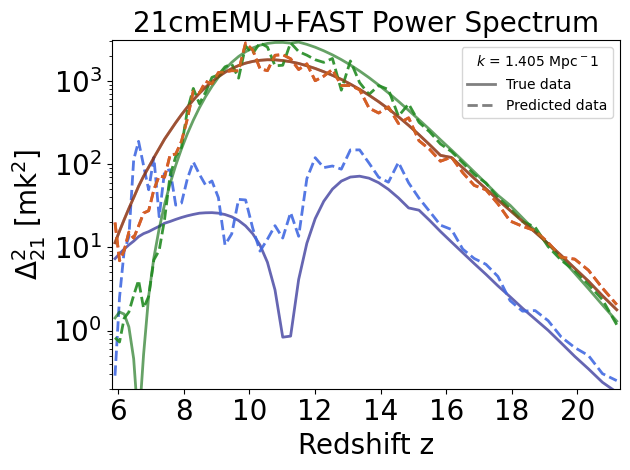

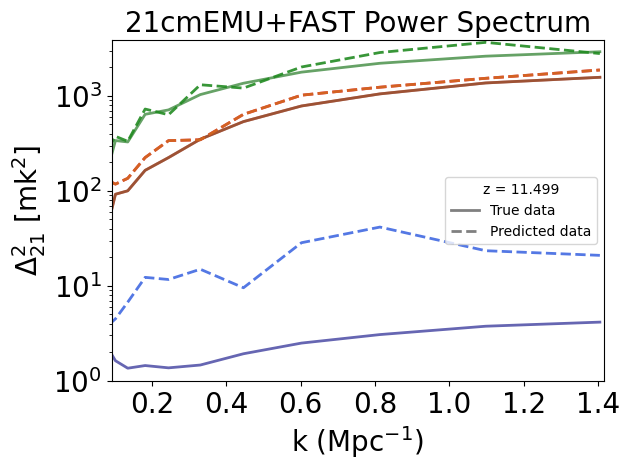

In [39]:
plotting_FAST_PS(fast_test_out, 10 ** y_pred_3D, 'zs', size = 4, k = 12, z = 10, filename = '21cmFAST_PS_k_0fixed_pipeline')
plotting_FAST_PS(fast_test_out, 10 ** y_pred_3D, 'k', size = 4, k = 5, z = 30, filename = '21cmFAST_PS_z_0fixed_pipeline')

IndexError: index 19966 is out of bounds for axis 0 with size 16

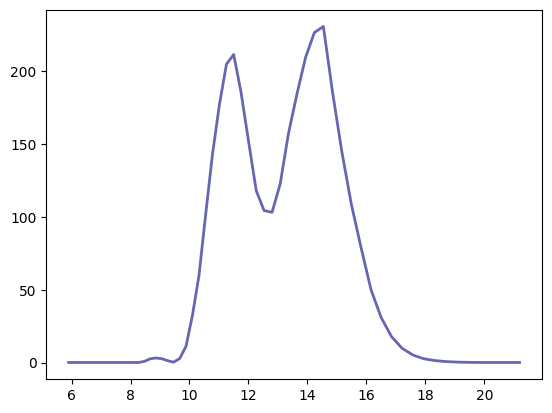

In [46]:
plotting_PS(final_test, 10 ** sig_y_pred_tens, 10 ** sharp_y_pred_tens, 'zs', size = 5, k = 3, z = 10, filename = '21cmFAST_PS_k_0fixed_freeze')
plotting_PS(final_test, 10 ** sig_y_pred_tens, 10 ** sharp_y_pred_tens, 'k', size = 5, k = 5, z = 10, filename = '21cmFAST_PS_z_0fixed_freeze')

In [47]:
saved_k_values = np.array([0.03820577, 0.05725007, 0.07778031, 0.101638,   0.1347107,  0.1815186,
 0.2444601,  0.3299734,  0.4460977,  0.6021986,  0.8131821,  1.097917, 1.4050565,  1.82823482])

In [48]:
saved_k_values[:-2]

array([0.03820577, 0.05725007, 0.07778031, 0.101638  , 0.1347107 ,
       0.1815186 , 0.2444601 , 0.3299734 , 0.4460977 , 0.6021986 ,
       0.8131821 , 1.097917  ])